<a href="https://colab.research.google.com/github/naserjam/Battery_Step_Response/blob/main/Battery_Step_Responce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Step Response of 314Ah / 0.5C cells**

REF:
Mohamed, M. A., Yu, T. F., Ramsden, G., Marco, J., & Grandjean, T. (2025).
Advancements in parameter estimation techniques for 1RC and 2RC
equivalent circuit models of lithium-ion batteries:
A comprehensive review. Journal of Energy Storage, 113, 115581.

AI: https://gemini.google.com/share/32ba11d4a60d

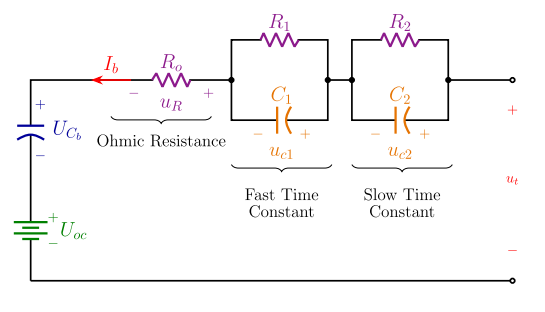

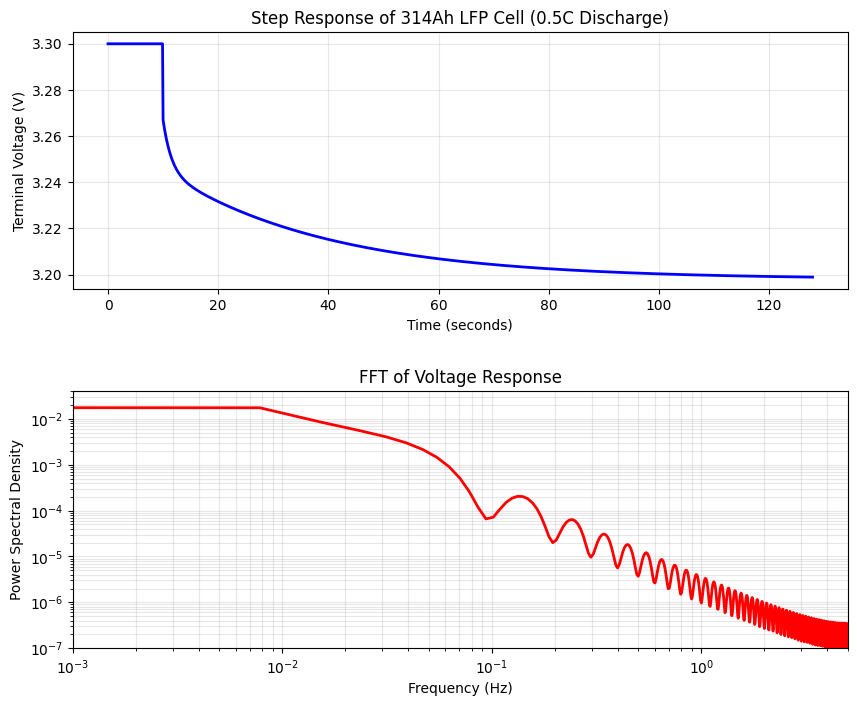

In [24]:
"""
Step Responce of 314Ah 0.5C cells

REF:
Mohamed, M. A., Yu, T. F., Ramsden, G., Marco, J., & Grandjean, T. (2025).
Advancements in parameter estimation techniques for 1RC and 2RC
equivalent circuit models of lithium-ion batteries:
A comprehensive review. Journal of Energy Storage, 113, 115581.
"""
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# --- 1. Cell Parameters (Typical 314Ah LFP) ---
Capacity_Ah = 314
I_step = Capacity_Ah / 2  # 0.5C = 157A
V_oc = 3.3                # Nominal Open Circuit Voltage (at mid-SOC)

# ECM Values (based on 314Ah scale)
R0 = 0.0002               # 0.2 mOhm
R1 = 0.00015              # 0.15 mOhm
C1 = 10000                # 10k Farads
R2 = 0.0003               # 0.3 mOhm
C2 = 100000               # 100k Farads

# --- 2. Simulation Setup ---
fs = 10                   # Sampling Frequency (Hz) - 100ms interval
duration = 128           # 128 seconds
t = np.arange(0, duration, 1/fs)

# Current Step: 0A before t=10s, 157A after t=10s
I = np.zeros_like(t)
I[t >= 10] = I_step

# --- 3. Step Response Calculation ---
def calculate_v_cell(t, I):
    V_cell = np.zeros_like(t)
    V_r1 = 0
    V_r2 = 0
    dt = 1/fs

    # Time constants
    tau1 = R1 * C1
    tau2 = R2 * C2

    for i in range(len(t)):
        # Discrete integration of RC voltages
        V_r1 = V_r1 * np.exp(-dt/tau1) + I[i] * R1 * (1 - np.exp(-dt/tau1))
        V_r2 = V_r2 * np.exp(-dt/tau2) + I[i] * R2 * (1 - np.exp(-dt/tau2))

        # Total Voltage = VOC - V_R0 - V_R1 - V_R2
        V_cell[i] = V_oc - (I[i] * R0) - V_r1 - V_r2
    return V_cell

V_signal = calculate_v_cell(t, I)

# --- 4. FFT Analysis ---
# We analyze the "Voltage Drop" signal (relative to V_oc)
V_drop = V_signal - V_oc
n = len(t)
yf = fft(V_drop)
xf = fftfreq(n, 1/fs)[:n//2]
#magnitude = (2.0/n * np.abs(yf[0:n//2]))
# Power Spectral Density:how energy is distributed over frequency
psd = (1.0 / (fs * n)) * np.abs(yf[0:n//2])**2


# --- 5. Plotting ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
plt.subplots_adjust(hspace=0.4)

# Plot 1: Step Response
ax1.plot(t, V_signal, color='blue', lw=2)
ax1.set_title(f'Step Response of 314Ah LFP Cell (0.5C Discharge)')
ax1.set_ylabel('Terminal Voltage (V)')
ax1.set_xlabel('Time (seconds)')
ax1.grid(True, alpha=0.3)

# Plot 2: FFT ( Power Spectral Density)
# Focus on low frequencies where battery dynamics live
#ax2.semilogy(xf, psd, color='red', lw=2)
ax2.loglog(xf, psd, color='red', lw=2)
ax2.set_title('FFT of Voltage Response')
ax2.set_ylabel('Power Spectral Density')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_xlim(1e-3, fs/2)
ax2.set_ylim(1e-7, 4*1e-2)
ax2.grid(True, which="both", alpha=0.3)

plt.show()